# EDA with the Enhanced Dataset

Checking a linear correlation between the newly calculated variables, `kpar`, `xmiss_summed`, `chl_a_summed`, and `phaeo_summed` with `secchi`. Note that these are all the values at the photic zone of the corresponding baselines. 

In [1]:
import sys
print(sys.executable)
import matplotlib
print(matplotlib.__file__)

/Users/aarti/Downloads/Scripps/Scripps-Light-Attenuation-Capstone-Project/.scripps/bin/python
/Users/aarti/Downloads/Scripps/Scripps-Light-Attenuation-Capstone-Project/.scripps/lib/python3.11/site-packages/matplotlib/__init__.py


In [2]:
# imports
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

In [3]:
# Loading the Dataset
CACHE_DIR = Path('../Data/Parquet')
CACHE_DIR.mkdir(exist_ok=True)

def load_or_cache(csv_path, parquet_path, usecols=None):
    parquet_path = Path(parquet_path)

    if parquet_path.exists():
        print(f"Loading cached: {parquet_path}")
        return pd.read_parquet(parquet_path)

    print(f"Reading CSV: {csv_path}")
    df = pd.read_csv(
        csv_path,
        usecols=usecols,
        low_memory=False
    )

    # Normalize object columns so Parquet doesn't choke
    obj_cols = df.select_dtypes(include="object").columns
    if len(obj_cols) > 0:
        df[obj_cols] = df[obj_cols].astype("string")

    print(f"Caching → {parquet_path}")
    df.to_parquet(parquet_path)

    return df

enhanced_df = load_or_cache(
    '../Data/Enhanced.csv',
    CACHE_DIR / 'Enhanced.parquet'
)

Loading cached: ../Data/Parquet/Enhanced.parquet


In [17]:
# Checking if everything is numeric
for col in enhanced_df.columns:
    if enhanced_df[col].dtype != 'numeric':
        #print(f"Column '{col}' is of type '{enhanced_df[col].dtype}'.")
        enhanced_df[col] = pd.to_numeric(enhanced_df[col], errors='coerce')

#print(f"Column '{col}' is of type '{enhanced_df[col].dtype}'.")
# Checking for rows and columns, shape of the dataset
print(f"Dataset shape: {enhanced_df.shape}")

Dataset shape: (2388, 40)


Visualization saved to ../results/correlation_matrix_enhanced_dataset.png


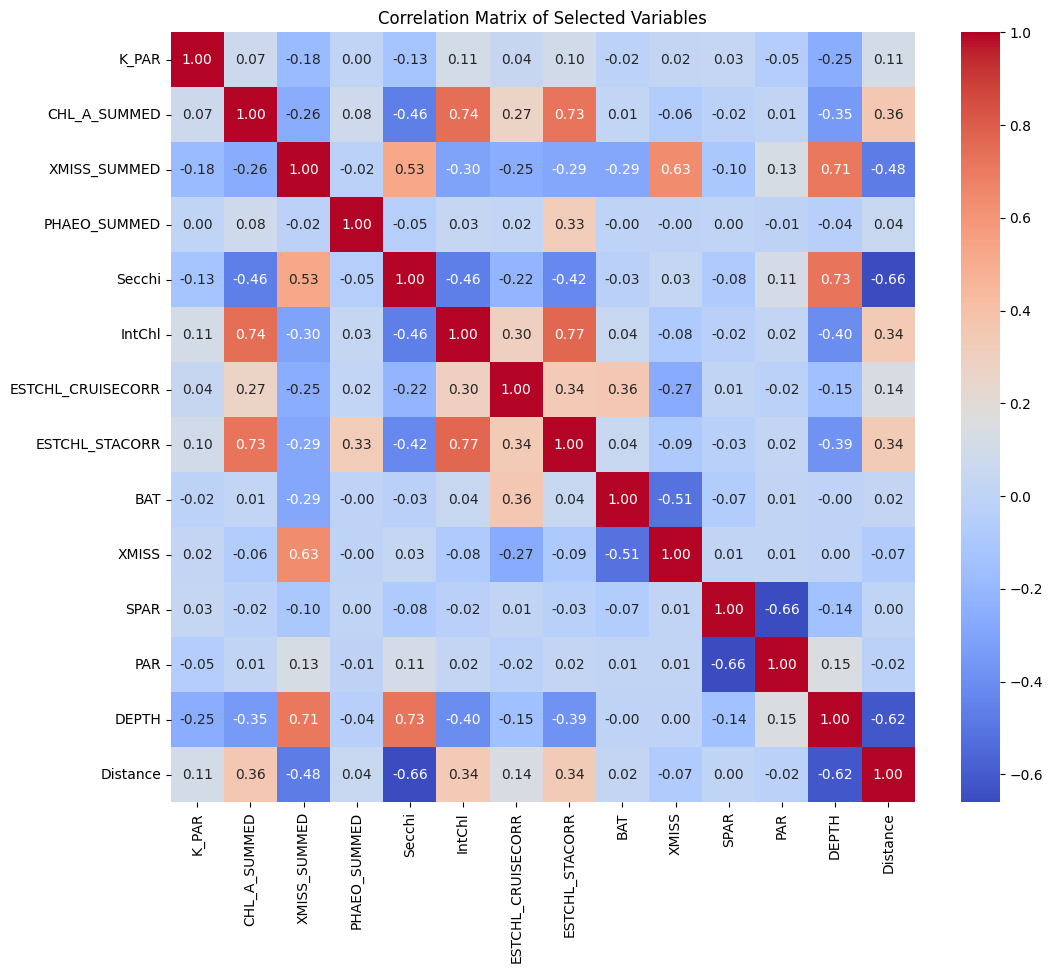

In [12]:
# Correlation analysis with variables kpar, chl_a_summed, xmiss_summed, phaeo_summed, secchi, depth, estchl_cruisecorr, 
# ESTCHL_STACORR	BAT	XMISS	SPAR	PAR
selected_columns = ['K_PAR', 'CHL_A_SUMMED', 'XMISS_SUMMED', 'PHAEO_SUMMED', 'Secchi', 
'IntChl', 'ESTCHL_CRUISECORR', 'ESTCHL_STACORR', 'BAT', 'XMISS', 'SPAR', 'PAR', 'DEPTH', 'Distance']
correlation_matrix = enhanced_df[selected_columns].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Selected Variables')

# Save correlation data
PLOT_PATH = Path("../results/correlation_matrix_enhanced_dataset.png")
plt.savefig(PLOT_PATH, dpi=300, bbox_inches='tight')
print(f"Visualization saved to {PLOT_PATH}")

plt.show()

# Simple scatter plots of new variables

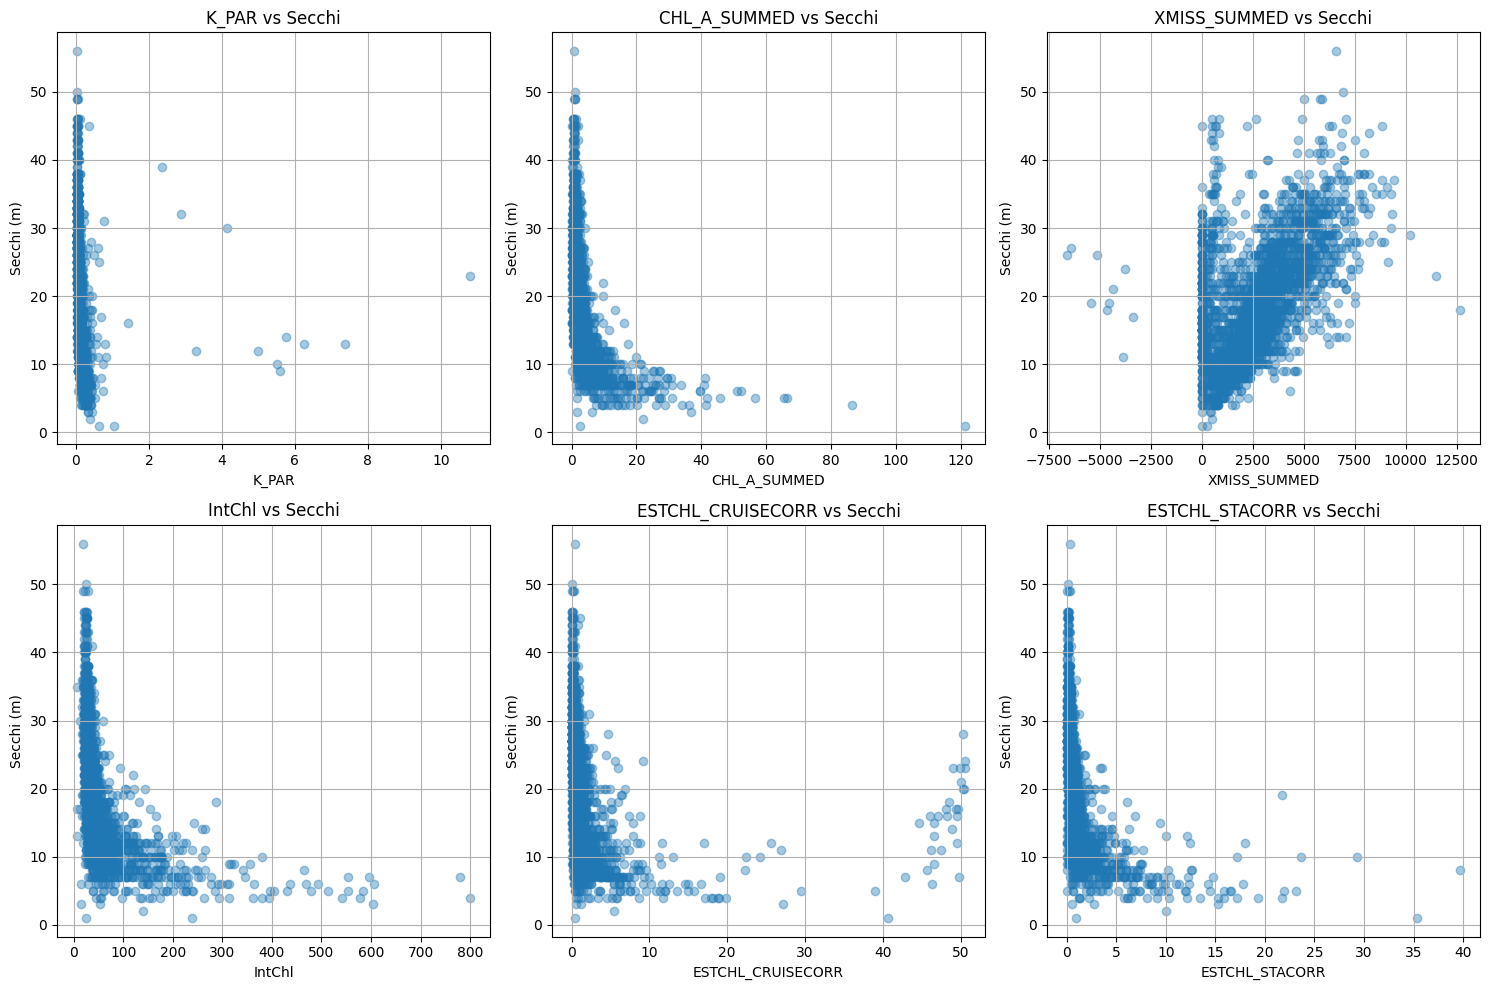

In [51]:
import matplotlib.pyplot as plt

vars_to_plot = ["K_PAR", "CHL_A_SUMMED", "XMISS_SUMMED", "IntChl", "ESTCHL_CRUISECORR", "ESTCHL_STACORR"]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, var in enumerate(vars_to_plot):
    axes[i].scatter(enhanced_df[var], enhanced_df["Secchi"], alpha=0.4)
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("Secchi (m)")
    axes[i].set_title(f"{var} vs Secchi")
    axes[i].grid(True)

plt.tight_layout()
plt.show()

Looking at the plots it seems like secchi is inversly proportional to KPAR. This is huge and coroborates with the literature we read. 

# Running Random Forest on the enhanced data

In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
import joblib

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.2s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.2s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.2s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.2s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.2s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=500; total time=   0.4s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=500; total time=   0.4s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=

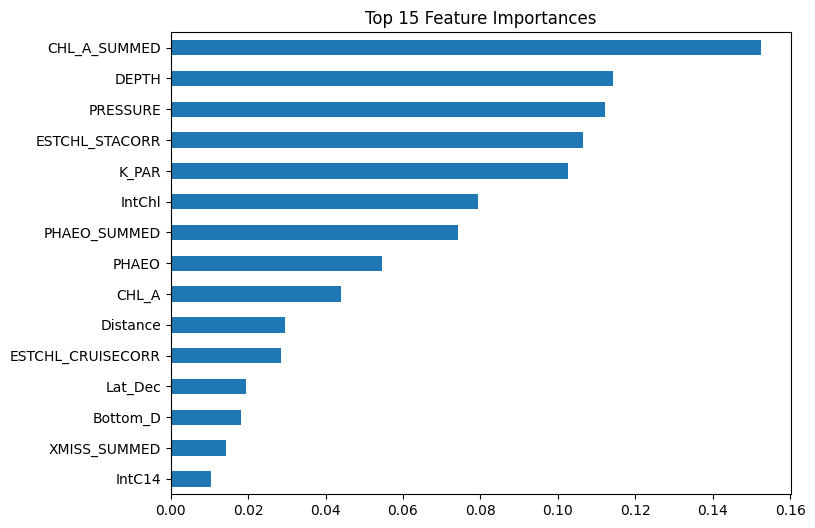

In [27]:
exclude_cols = ['ORD_OCC', 'CAST_ID', 'DATE_TIME_UTC', 'DATE_TIME_PST', 'LAT_DEC', 'LON_DEC', 'STA_ID', 'LINE', 'STA',
'CAST_COUNT','Cruise_ID','Cruz_Sta','Date','Time','TimeZone','PHOTIC_ZONE']

# Feature columns for modeling, not in exclude_cols
feature_cols = [col for col in enhanced_df.columns if col not in exclude_cols]

models_dir = Path("../Models")
models_dir.mkdir(exist_ok=True)

target_col = "Secchi"

feature_cols = [col for col in enhanced_df.columns if col not in exclude_cols + [target_col]]

X = enhanced_df[feature_cols].copy()
y = enhanced_df[target_col].copy()

# Drop rows with NA
mask = X.notna().all(axis=1) & y.notna()
X = X[mask]
y = y[mask]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

rf = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [200, 500, 1000],
    "max_features": ["sqrt", 0.3, 0.5],   # m_try
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",  # better than MSE
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

y_pred = best_rf.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"Test RMSE: {rmse:.4f}")
print(f"Test R²: {r2:.4f}")

model_path = models_dir / "enhanced_random_forest_model.pkl"
joblib.dump(best_rf, model_path)
print(f"Model saved to {model_path}")

importances = pd.Series(best_rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8,6))
importances.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances")
plt.show()

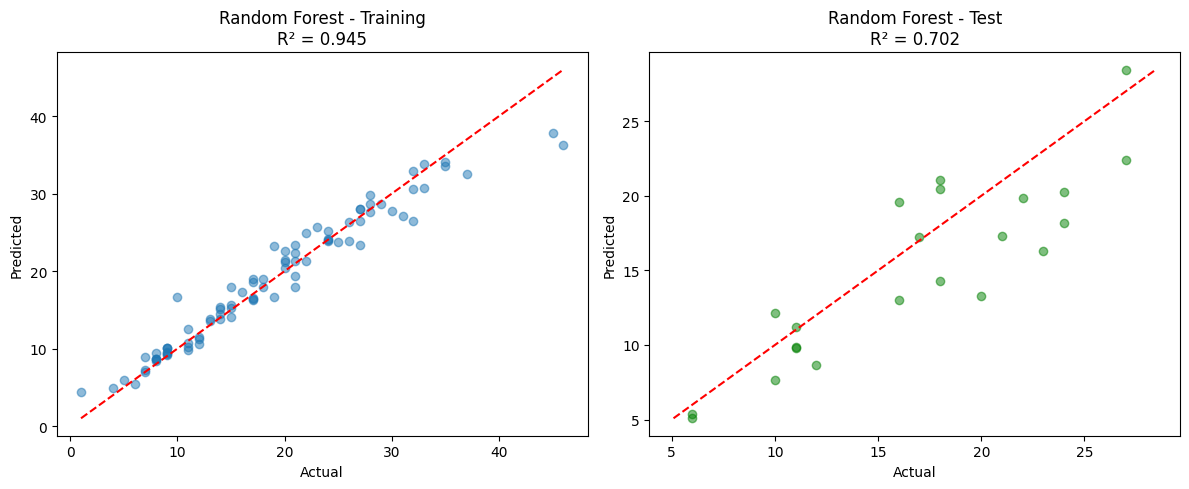

In [29]:
results = {}

# Training predictions
y_train_pred = best_rf.predict(X_train)
y_test_pred = best_rf.predict(X_test)

results["random_forest"] = {
    "y_train": y_train,
    "y_train_pred": y_train_pred,
    "y_test": y_test,
    "y_test_pred": y_test_pred,
    "train_r2": r2_score(y_train, y_train_pred),
    "test_r2": r2_score(y_test, y_test_pred)
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Training
axes[0].scatter(y_train, y_train_pred, alpha=0.5)
min_val = min(y_train.min(), y_train_pred.min())
max_val = max(y_train.max(), y_train_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--')
axes[0].set_title(f"Random Forest - Training\nR² = {results['random_forest']['train_r2']:.3f}")
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")

# Test
axes[1].scatter(y_test, y_test_pred, alpha=0.5, color='green')
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--')
axes[1].set_title(f"Random Forest - Test\nR² = {results['random_forest']['test_r2']:.3f}")
axes[1].set_xlabel("Actual")
axes[1].set_ylabel("Predicted")

plt.tight_layout()
plt.show()

# Excluding baseline of 1 (Fail)

In [30]:
excluded_df = enhanced_df[enhanced_df['baseline_depth']!=1].copy()

print("Filtered rows:", len(excluded_df))

Filtered rows: 1787


Fitting 5 folds for each of 324 candidates, totalling 1620 fits
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.2s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.2s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.2s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.2s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.2s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=500; total time=   0.5s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=500; total time=   0.5s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=

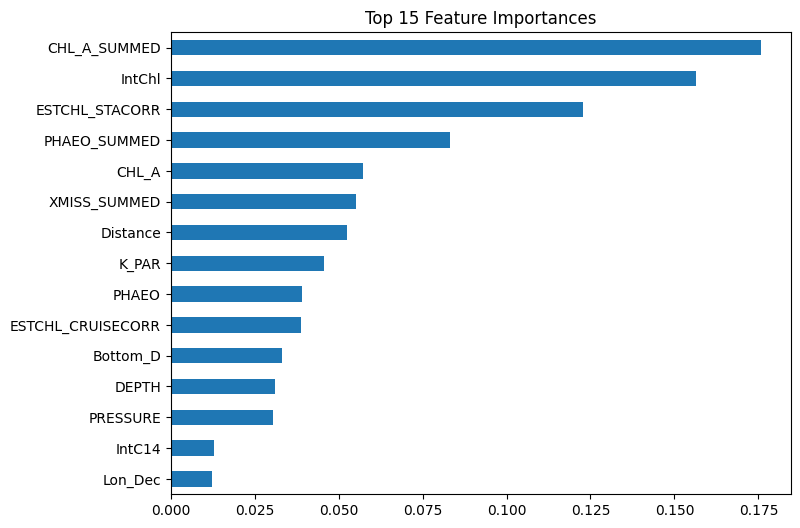

In [31]:
exclude_cols = ['ORD_OCC', 'CAST_ID', 'DATE_TIME_UTC', 'DATE_TIME_PST', 'LAT_DEC', 'LON_DEC', 'STA_ID', 'LINE', 'STA',
'CAST_COUNT','Cruise_ID','Cruz_Sta','Date','Time','TimeZone','PHOTIC_ZONE']

target_col = "Secchi"

# IMPORTANT: build from filtered_df
feature_cols = [col for col in excluded_df.columns if col not in exclude_cols + [target_col]]

X = excluded_df[feature_cols].copy()
y = excluded_df[target_col].copy()

mask = X.notna().all(axis=1) & y.notna()
X = X[mask]
y = y[mask]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

rf = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [200, 500, 1000],
    "max_features": ["sqrt", 0.3, 0.5],   # m_try
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",  # better than MSE
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

y_pred = best_rf.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"Test RMSE: {rmse:.4f}")
print(f"Test R²: {r2:.4f}")

model_path = models_dir / "enhanced_random_forest_model.pkl"
joblib.dump(best_rf, model_path)
print(f"Model saved to {model_path}")

importances = pd.Series(best_rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8,6))
importances.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances")
plt.show()

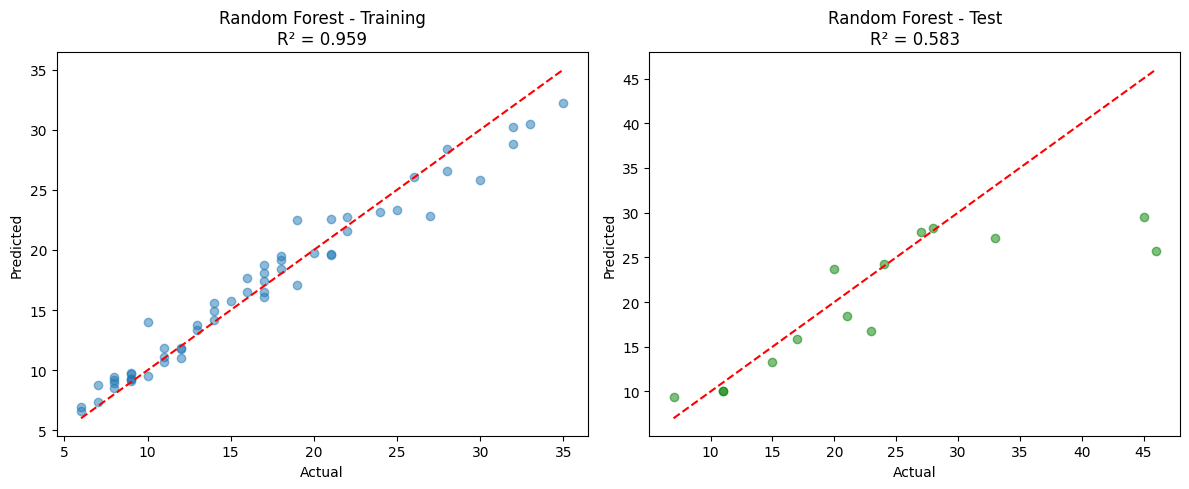

In [32]:
results = {}

# Training predictions
y_train_pred = best_rf.predict(X_train)
y_test_pred = best_rf.predict(X_test)

results["random_forest"] = {
    "y_train": y_train,
    "y_train_pred": y_train_pred,
    "y_test": y_test,
    "y_test_pred": y_test_pred,
    "train_r2": r2_score(y_train, y_train_pred),
    "test_r2": r2_score(y_test, y_test_pred)
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Training
axes[0].scatter(y_train, y_train_pred, alpha=0.5)
min_val = min(y_train.min(), y_train_pred.min())
max_val = max(y_train.max(), y_train_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--')
axes[0].set_title(f"Random Forest - Training\nR² = {results['random_forest']['train_r2']:.3f}")
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")

# Test
axes[1].scatter(y_test, y_test_pred, alpha=0.5, color='green')
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--')
axes[1].set_title(f"Random Forest - Test\nR² = {results['random_forest']['test_r2']:.3f}")
axes[1].set_xlabel("Actual")
axes[1].set_ylabel("Predicted")

plt.tight_layout()
plt.show()

# Log Transform Secchi

Final sample size: 108
Fitting 5 folds for each of 324 candidates, totalling 1620 fits
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   0.4s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   0.3s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   0.4s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   0.4s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   0.5s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=600; total time=   0.8s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=600; total time=   0.8s
[CV] END max_depth=None, max_features=sqrt, min_samples_lea

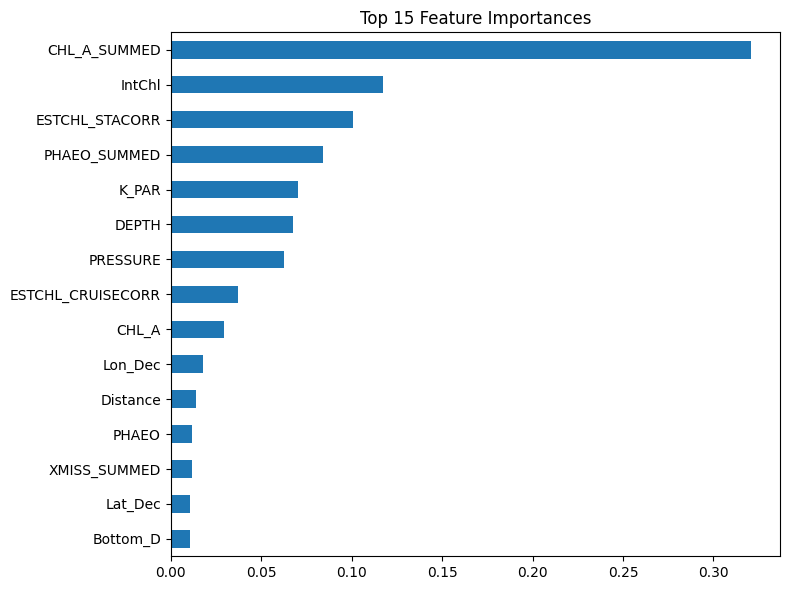

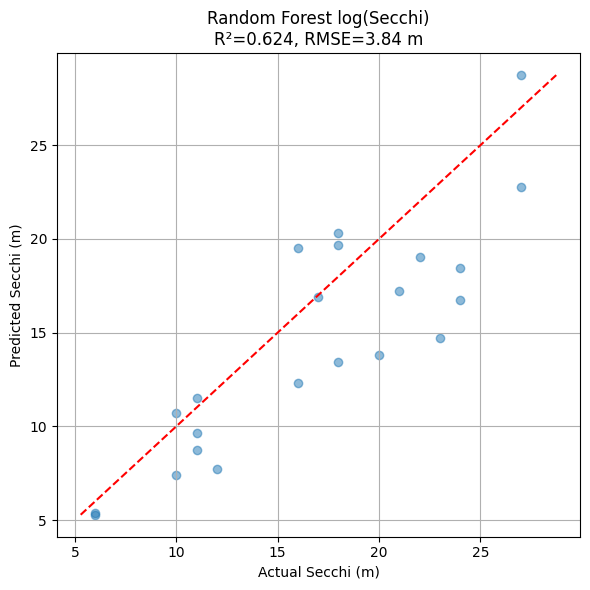

In [52]:
# ===============================

# Random Forest predicting log(Secchi)

# ===============================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# -------------------------------

# 1. Define columns

# -------------------------------

exclude_cols = [
'ORD_OCC','CAST_ID','DATE_TIME_UTC','DATE_TIME_PST','LAT_DEC','LON_DEC',
'STA_ID','LINE','STA','CAST_COUNT','Cruise_ID','Cruz_Sta','Date','Time',
'TimeZone','PHOTIC_ZONE'
]

target_col = "Secchi"

# IMPORTANT: remove target from predictors (prevents leakage)

feature_cols = [c for c in enhanced_df.columns if c not in exclude_cols + [target_col]]

# -------------------------------

# 2. Build X and y

# -------------------------------

X = enhanced_df[feature_cols].copy()
y = enhanced_df[target_col].copy()

# remove impossible values

mask = (y > 0) & y.notna() & X.notna().all(axis=1)
X = X[mask]
y = y[mask]

# log-transform target

y_log = np.log(y)

print("Final sample size:", len(X))

# -------------------------------

# 3. Train/Test split

# -------------------------------

X_train, X_test, y_train_log, y_test_log = train_test_split(
X, y_log,
test_size=0.2,
random_state=42
)

# -------------------------------

# 4. Random Forest + Hyperparameter tuning

# -------------------------------

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

param_grid = {
"n_estimators": [300, 600, 1000],
"max_features": ["sqrt", 0.3, 0.5],
"max_depth": [None, 10, 20, 30],
"min_samples_split": [2, 5, 10],
"min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
rf,
param_grid,
cv=5,
scoring="neg_mean_squared_error",
verbose=2,
n_jobs=-1
)

grid_search.fit(X_train, y_train_log)

best_rf = grid_search.best_estimator_

print("\nBest Parameters:")
print(grid_search.best_params_)

# -------------------------------

# 5. Predict (back-transform)

# -------------------------------

y_pred_log = best_rf.predict(X_test)

# convert back to meters

y_pred = np.exp(y_pred_log)
y_test = np.exp(y_test_log)

# -------------------------------

# 6. Metrics (on real Secchi scale)

# -------------------------------

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"\nTest RMSE (meters): {rmse:.3f}")
print(f"Test R²: {r2:.3f}")

# -------------------------------

# 7. Save model

# -------------------------------

models_dir = Path("../Models")
models_dir.mkdir(exist_ok=True)

model_path = models_dir / "RF_logSecchi_model.pkl"
joblib.dump(best_rf, model_path)

print(f"Model saved to {model_path}")

# -------------------------------

# 8. Feature Importance

# -------------------------------

importances = pd.Series(best_rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8,6))
importances.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances")
plt.tight_layout()
plt.show()

# -------------------------------

# 9. Actual vs Predicted plot

# -------------------------------

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], 'r--')
plt.xlabel("Actual Secchi (m)")
plt.ylabel("Predicted Secchi (m)")
plt.title(f"Random Forest log(Secchi)\nR²={r2:.3f}, RMSE={rmse:.2f} m")
plt.grid(True)
plt.tight_layout()
plt.show()

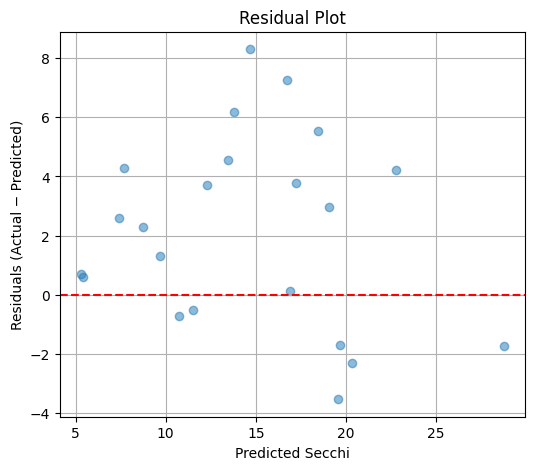

In [53]:
residuals = y_test - y_pred

plt.figure(figsize=(6,5))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Secchi")
plt.ylabel("Residuals (Actual − Predicted)")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

# Physics Informed Feature Engineering

Final sample size: 108
Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END learning_rate=0.05, max_depth=None, max_iter=300, min_samples_leaf=50; total time=   0.1s
[CV] END learning_rate=0.05, max_depth=None, max_iter=300, min_samples_leaf=50; total time=   0.2s
[CV] END learning_rate=0.05, max_depth=None, max_iter=300, min_samples_leaf=50; total time=   0.1s
[CV] END learning_rate=0.05, max_depth=None, max_iter=300, min_samples_leaf=20; total time=   0.2s
[CV] END learning_rate=0.05, max_depth=None, max_iter=300, min_samples_leaf=20; total time=   0.2s
[CV] END learning_rate=0.05, max_depth=None, max_iter=300, min_samples_leaf=20; total time=   0.2s
[CV] END learning_rate=0.05, max_depth=None, max_iter=300, min_samples_leaf=50; total time=   0.0s
[CV] END learning_rate=0.05, max_depth=None, max_iter=300, min_samples_leaf=20; total time=   0.2s
[CV] END learning_rate=0.05, max_depth=None, max_iter=300, min_samples_leaf=20; total time=   0.2s
[CV] END learning_rate=0

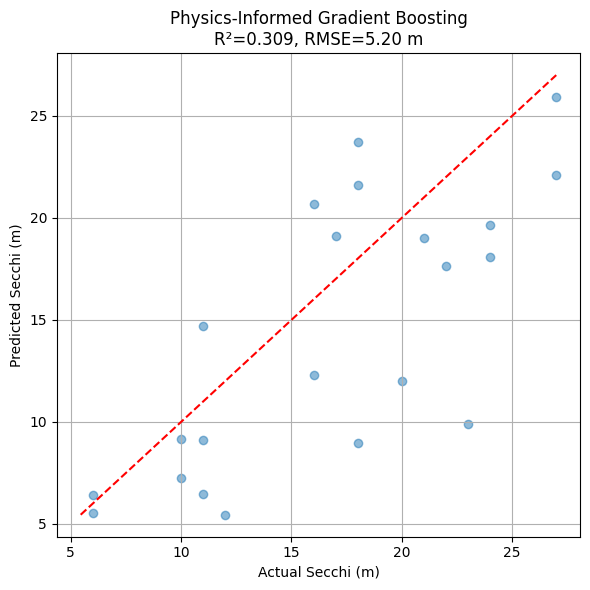

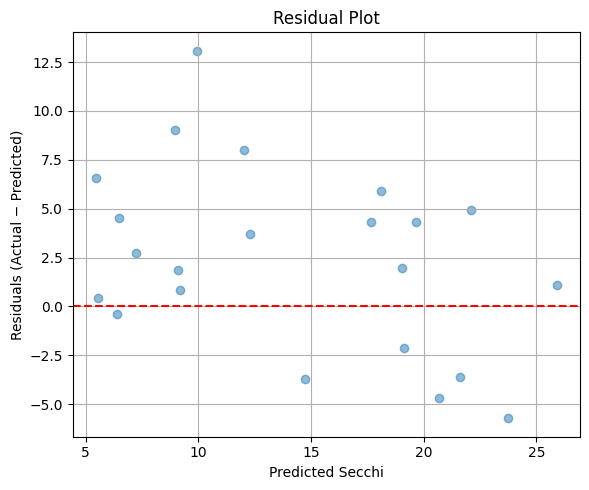

In [54]:
# ============================================
# PHYSICS-INFORMED MODEL (Better than RF)
# ============================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error

# --------------------------------------------
# 1. Feature Engineering (Physics Features)
# --------------------------------------------

df = enhanced_df.copy()

# Avoid division by zero
eps = 1e-6

df["inv_KPAR"] = 1 / (df["K_PAR"] + eps)
df["log_chl"] = np.log(df["CHL_A_SUMMED"] + 0.01)
df["chl_per_depth"] = df["IntChl"] / (df["DEPTH"] + 1)
df["xm_per_kpar"] = df["XMISS"] / (df["K_PAR"] + eps)
df["par_attenuation"] = df["PAR"] / (df["K_PAR"] + eps)

# --------------------------------------------
# 2. Define features and target
# --------------------------------------------

exclude_cols = [
    'ORD_OCC','CAST_ID','DATE_TIME_UTC','DATE_TIME_PST','LAT_DEC','LON_DEC',
    'STA_ID','LINE','STA','CAST_COUNT','Cruise_ID','Cruz_Sta','Date','Time',
    'TimeZone','PHOTIC_ZONE'
]

target_col = "Secchi"

feature_cols = [c for c in df.columns if c not in exclude_cols + [target_col]]

X = df[feature_cols].copy()
y = df[target_col].copy()

# Remove invalid values
mask = (y > 0) & y.notna() & X.notna().all(axis=1)
X = X[mask]
y = y[mask]

# Log-transform target
y_log = np.log(y)

print("Final sample size:", len(X))

# --------------------------------------------
# 3. Train/Test Split
# --------------------------------------------

X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log,
    test_size=0.2,
    random_state=42
)

# --------------------------------------------
# 4. HistGradientBoosting Model
# --------------------------------------------

model = HistGradientBoostingRegressor(random_state=42)

param_grid = {
    "learning_rate": [0.05, 0.1],
    "max_depth": [None, 10, 20],
    "max_iter": [300, 600],
    "min_samples_leaf": [20, 50]
}

grid_search = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train_log)

best_model = grid_search.best_estimator_

print("\nBest Parameters:")
print(grid_search.best_params_)

# --------------------------------------------
# 5. Predict (Back-transform)
# --------------------------------------------

y_pred_log = best_model.predict(X_test)

y_pred = np.exp(y_pred_log)
y_test = np.exp(y_test_log)

# --------------------------------------------
# 6. Metrics
# --------------------------------------------

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\nTest RMSE (meters): {rmse:.3f}")
print(f"Test R²: {r2:.3f}")

# --------------------------------------------
# 7. Save Model
# --------------------------------------------

models_dir = Path("../Models")
models_dir.mkdir(exist_ok=True)

model_path = models_dir / "GradientBoost_logSecchi.pkl"
joblib.dump(best_model, model_path)

print(f"Model saved to {model_path}")

# --------------------------------------------
# 8. Actual vs Predicted Plot
# --------------------------------------------

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], 'r--')
plt.xlabel("Actual Secchi (m)")
plt.ylabel("Predicted Secchi (m)")
plt.title(f"Physics-Informed Gradient Boosting\nR²={r2:.3f}, RMSE={rmse:.2f} m")
plt.grid(True)
plt.tight_layout()
plt.show()

# --------------------------------------------
# 9. Residual Plot
# --------------------------------------------

residuals = y_test - y_pred

plt.figure(figsize=(6,5))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Secchi")
plt.ylabel("Residuals (Actual − Predicted)")
plt.title("Residual Plot")
plt.grid(True)
plt.tight_layout()
plt.show()